In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib import rcParams
import pandas as pd
import seaborn as sns

matplotlib_font_size = 7
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Helvetica']
rcParams['font.size'] = matplotlib_font_size

repo_root = Path.cwd().parent.parent
path_figures = repo_root / 'figures'
path_figures.mkdir(parents=True, exist_ok=True)
path_benchmark_data = repo_root / 'benchmark_search_global_repository'

In [23]:
steps = ['open_search', 'neutral_loss_search', 'hybrid_search']
query_sizes = [1, 10, 100, 1000]
ion_modes = [-1, 1]

In [24]:
records = []
for query_size in query_sizes:
    for charge in ion_modes:
        data_dir = path_benchmark_data / f'query_num_{query_size}_charge_{charge}'
        for step in steps:
            for query_idx in range(query_size):
                data_file = data_dir / (
                    f'repository_{charge}_repository_memory_usage_{step}_step_query_{query_idx}.txt'
                )
                maximum_rss_kb = None
                with data_file.open() as handle:
                    for line in handle:
                        key, separator, value = line.partition(':')
                        if separator and key.strip() == 'Maximum resident set size (kbytes)':
                            maximum_rss_kb = int(value.strip())
                            break
                if maximum_rss_kb is None:
                    raise ValueError(f'Maximum resident set size not found in {data_file}')
                records.append({
                    'query_size': query_size,
                    'query_idx': query_idx,
                    'charge': charge,
                    'search_type': step,
                    'memory_gb': maximum_rss_kb / 1048576,
                })

df = pd.DataFrame.from_records(records)
df

,query_size,query_idx,charge,search_type,memory_gb
0,1,0,-1,open_search,0.198509
1,1,0,-1,neutral_loss_search,0.186356
2,1,0,-1,hybrid_search,0.256283
3,1,0,1,open_search,0.205456
4,1,0,1,neutral_loss_search,0.224583
...,...,...,...,...,...
6661,1000,995,1,hybrid_search,0.437401
6662,1000,996,1,hybrid_search,0.338043
6663,1000,997,1,hybrid_search,0.456814
6664,1000,998,1,hybrid_search,0.401985


In [25]:
df_data = df[['query_size', 'query_idx', 'charge', 'search_type', 'memory_gb']]
df_data

,query_size,query_idx,charge,search_type,memory_gb
0,1,0,-1,open_search,0.198509
1,1,0,-1,neutral_loss_search,0.186356
2,1,0,-1,hybrid_search,0.256283
3,1,0,1,open_search,0.205456
4,1,0,1,neutral_loss_search,0.224583
...,...,...,...,...,...
6661,1000,995,1,hybrid_search,0.437401
6662,1000,996,1,hybrid_search,0.338043
6663,1000,997,1,hybrid_search,0.456814
6664,1000,998,1,hybrid_search,0.401985


In [26]:
def plot_memory_different_query_num_repository(
    df, search_type, color_palette, ylim, save_path
):
    fig, axes = plt.subplots(1, 2, figsize=(6, 2.8), sharex=True, sharey=True)
    search_data = df[df['search_type'] == search_type]

    for idx, charge in enumerate(ion_modes):
        ax = axes[idx]
        subset = search_data[search_data['charge'] == charge]
        sns.boxplot(data=subset, x='query_size', y='memory_gb', order=query_sizes,
                    color=color_palette[charge], width=0.5, linewidth=0.4,
                    fliersize=0, ax=ax)
        sns.stripplot(data=subset, x='query_size', y='memory_gb', order=query_sizes,
                      color=color_palette[charge], jitter=0.18, size=1,
                      alpha=0.3, linewidth=0, ax=ax)
        medians = subset.groupby('query_size')['memory_gb'].median().reindex(query_sizes)
        ax.plot(range(len(query_sizes)), medians, color=color_palette[charge],
                marker='o', markersize=2.5, linewidth=0.8, zorder=4)
        ax.set_ylim(ylim)
        ax.set_title(charge_labels[charge])
        ax.set_xlabel('Number of query spectra')
        ax.set_ylabel('Library Search Memory Usage (GB)' if idx == 0 else '')
        ax.grid(True, which='both', axis='y', alpha=0.5, linewidth=0.3)
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)
        ax.tick_params(axis='both', which='both', width=0.5)

    fig.suptitle(search_type.replace('_', ' ').title())
    fig.tight_layout()
    fig.savefig(save_path, bbox_inches='tight', dpi=1200)
    return fig, axes

In [27]:
color_palette = {
    1: '#FCD470',
    -1: '#66BC98'
}
charge_labels = {-1: '(-) ESI', 1: '(+) ESI'}

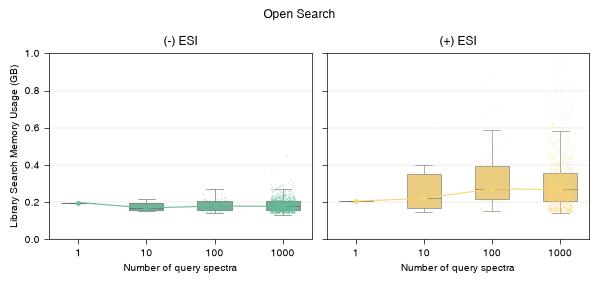

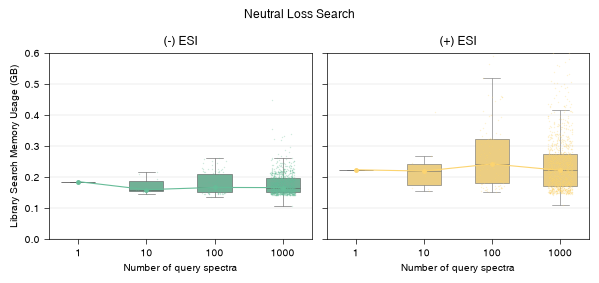

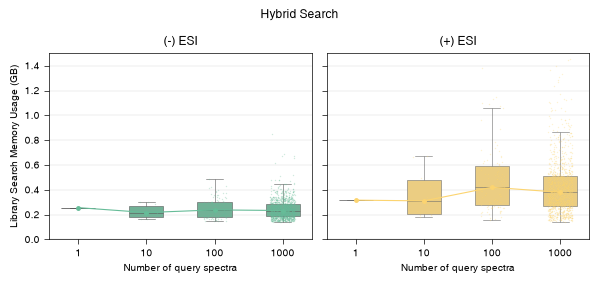

In [28]:
every_ylim = {
    'open_search': (0, 1.0),
    'neutral_loss_search': (0, 0.6),
    'hybrid_search': (0, 1.5),
}
figures = {}
for search_type in steps:
    save_path = path_figures / f'compare_memory_different_query_num_repository_{search_type}.svg'
    figures[search_type] = plot_memory_different_query_num_repository(
        df=df, search_type=search_type, color_palette=color_palette,
        ylim=every_ylim[search_type], save_path=save_path
    )[0]